# Tesla Deliveries ML Pipeline (2015–2025)
### End-to-end: EDA · Feature Engineering · Regression · Hyperparameter Tuning · Time Series Forecasting

## 1. ML Pipeline

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('/content/drive/MyDrive/tesla_deliveries_dataset_2015_2025.csv')
print(df.shape)
df.head()

(2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
print(df.dtypes)
print()
print(df.describe())

Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000           2640.000000       2640.000000   
mean   2020.000000     6.500000           9922.199621      10655.847348   
std       3.162877     3.452707           3935.950093       4260.600858   
min    2015.000000     1.000000             48.000000         50.000000   
25%    2017.000000     3.750000           7292.000000       7828.250000   
50%    2020.000000     6.500000           9857.000000      10546.500000   
75%    2023.000000     9.250000          12510.250000      13469.000000   
m

## 2. Bias-Variance Tradeoff

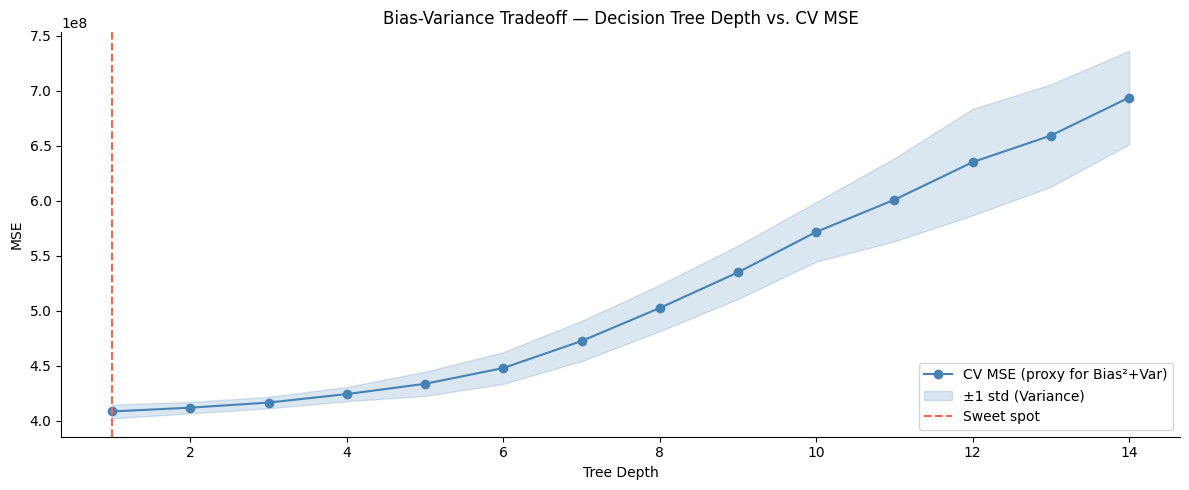

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

tmp = df[['Year', 'Month', 'Battery_Capacity_kWh', 'Range_km',
          'Charging_Stations', 'Avg_Price_USD']].dropna()

X_tmp = tmp.drop('Avg_Price_USD', axis=1)
y_tmp = tmp['Avg_Price_USD']

depths = list(range(1, 15))
bias_sq, variance = [], []

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    scores = cross_val_score(model, X_tmp, y_tmp, cv=5, scoring='neg_mean_squared_error')
    mse_scores = -scores
    bias_sq.append(mse_scores.mean())
    variance.append(mse_scores.std())

fig, ax = plt.subplots()
ax.plot(depths, bias_sq, label='CV MSE (proxy for Bias²+Var)', marker='o', color='steelblue')
ax.fill_between(depths,
                [b - v for b, v in zip(bias_sq, variance)],
                [b + v for b, v in zip(bias_sq, variance)],
                alpha=0.2, color='steelblue', label='±1 std (Variance)')
ax.axvline(x=depths[np.argmin(bias_sq)], color='tomato', linestyle='--', label='Sweet spot')
ax.set_xlabel('Tree Depth')
ax.set_ylabel('MSE')
ax.set_title('Bias-Variance Tradeoff — Decision Tree Depth vs. CV MSE')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Overfitting and Underfitting

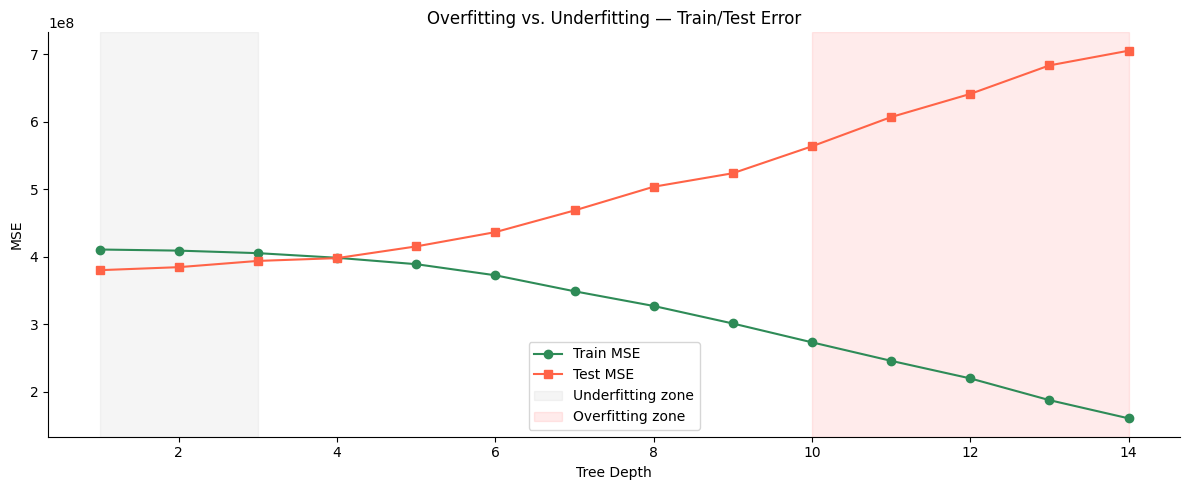

In [5]:
from sklearn.model_selection import train_test_split

X_tmp2 = tmp.drop('Avg_Price_USD', axis=1)
y_tmp2 = tmp['Avg_Price_USD']

X_tr, X_te, y_tr, y_te = train_test_split(X_tmp2, y_tmp2, test_size=0.2, random_state=42)

train_errors, test_errors = [], []

for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(X_tr, y_tr)
    train_errors.append(np.mean((m.predict(X_tr) - y_tr)**2))
    test_errors.append(np.mean((m.predict(X_te) - y_te)**2))

fig, ax = plt.subplots()
ax.plot(depths, train_errors, label='Train MSE', marker='o', color='seagreen')
ax.plot(depths, test_errors,  label='Test MSE',  marker='s', color='tomato')
ax.axvspan(1, 3,  alpha=0.08, color='gray',  label='Underfitting zone')
ax.axvspan(10, 14, alpha=0.08, color='red',  label='Overfitting zone')
ax.set_xlabel('Tree Depth')
ax.set_ylabel('MSE')
ax.set_title('Overfitting vs. Underfitting — Train/Test Error')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Data Cleaning

In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicated rows:", df.duplicated().sum())

Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicated rows: 0


In [7]:
df_clean = df.copy()

df_clean = df_clean.drop_duplicates()

for col in df_clean.select_dtypes(include='number').columns:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    before = len(df_clean)
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    removed = before - len(df_clean)
    if removed:
        print(f"{col}: removed {removed} outlier rows")

print()
print("Shape after cleaning:", df_clean.shape)

Estimated_Deliveries: removed 12 outlier rows
Production_Units: removed 3 outlier rows
CO2_Saved_tons: removed 40 outlier rows

Shape after cleaning: (2585, 12)


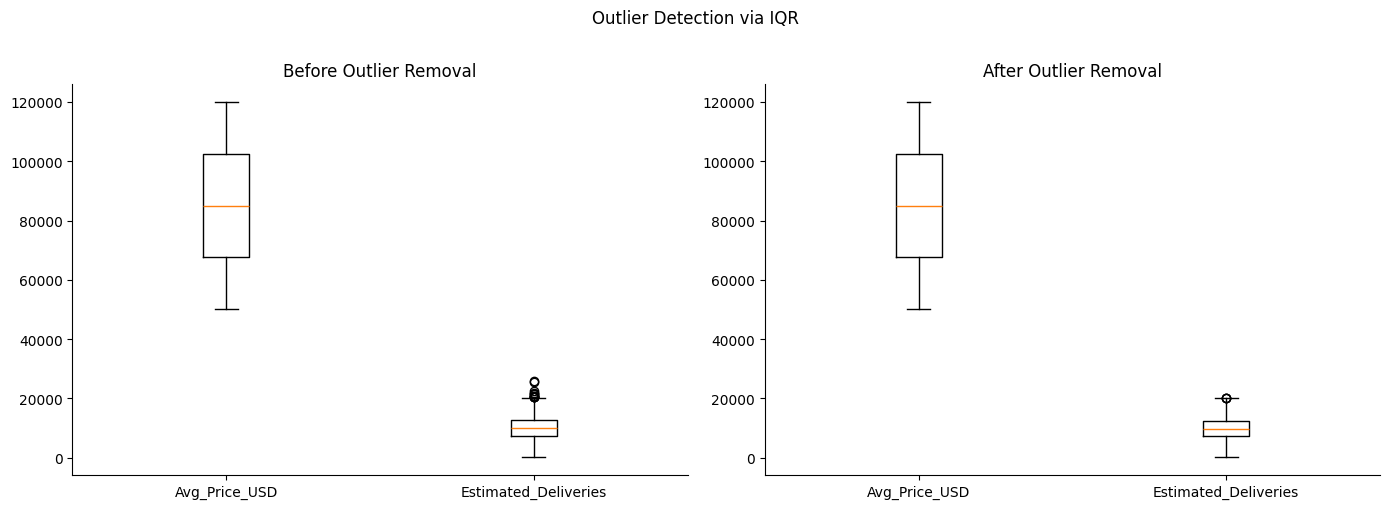

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([df['Avg_Price_USD'], df['Estimated_Deliveries']],
               labels=['Avg_Price_USD', 'Estimated_Deliveries'])
axes[0].set_title('Before Outlier Removal')

axes[1].boxplot([df_clean['Avg_Price_USD'], df_clean['Estimated_Deliveries']],
               labels=['Avg_Price_USD', 'Estimated_Deliveries'])
axes[1].set_title('After Outlier Removal')

plt.suptitle('Outlier Detection via IQR', y=1.01)
plt.tight_layout()
plt.show()

## 5. Exploratory Data Analysis (EDA)

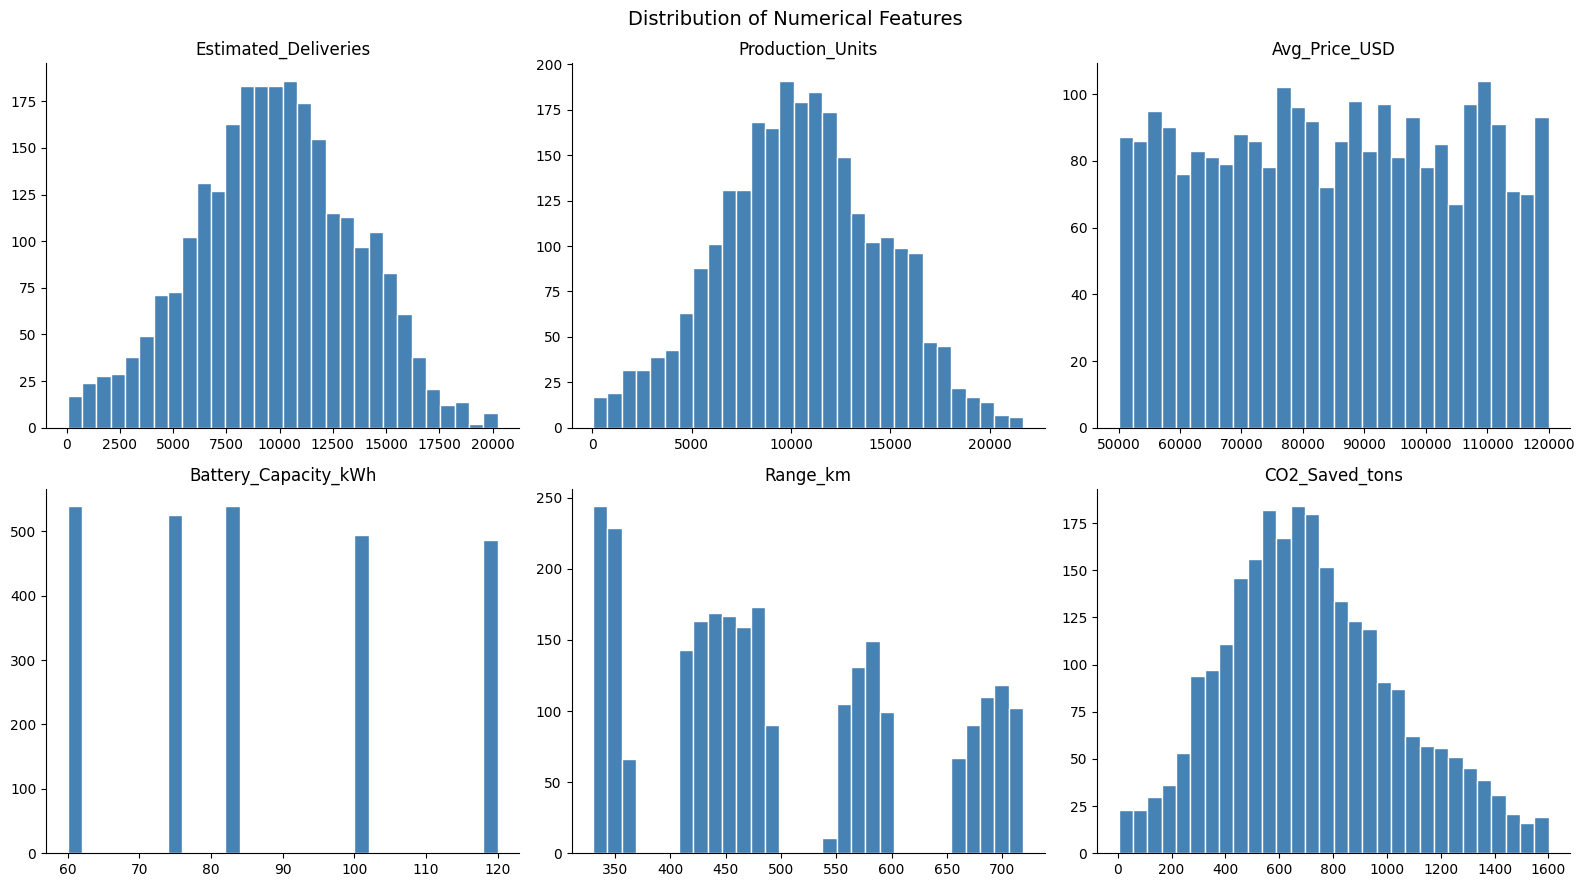

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
num_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons']

for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df_clean[col], bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Distribution of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

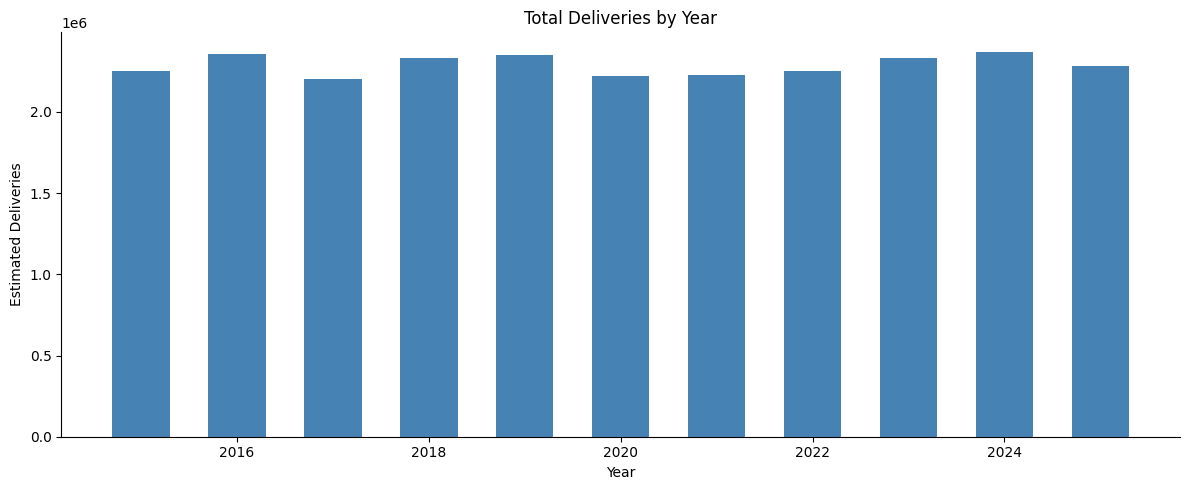

In [10]:
yearly = df_clean.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

fig, ax = plt.subplots()
ax.bar(yearly['Year'], yearly['Estimated_Deliveries'], color='steelblue', width=0.6)
ax.set_title('Total Deliveries by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Estimated Deliveries')
plt.tight_layout()
plt.show()

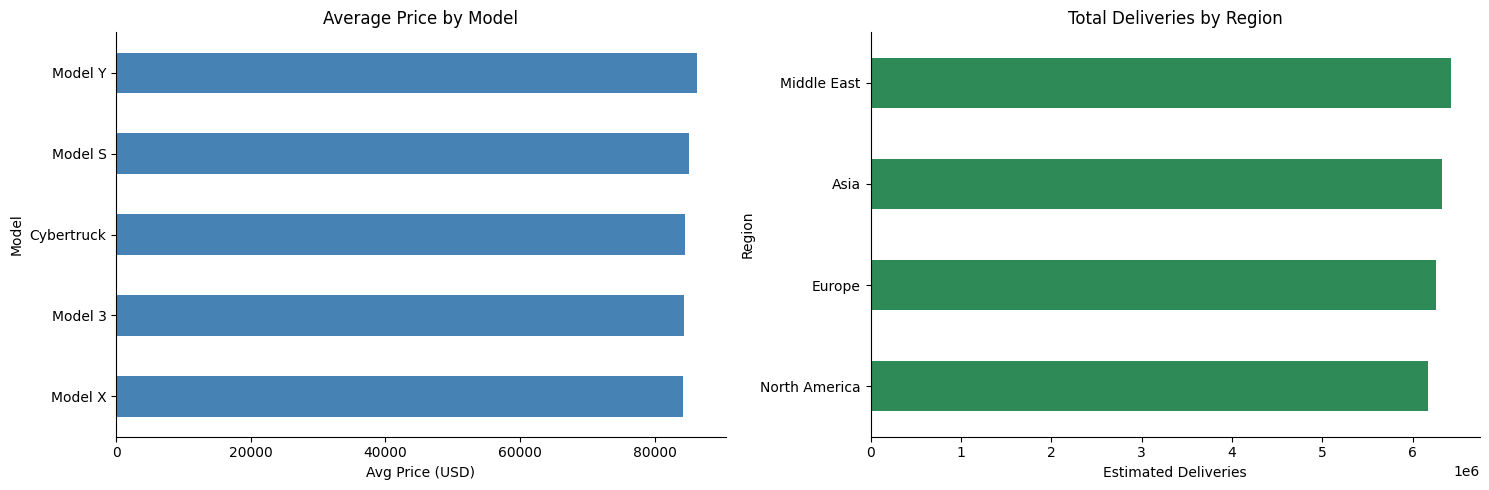

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

model_avg = df_clean.groupby('Model')['Avg_Price_USD'].mean().sort_values()
model_avg.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Average Price by Model')
axes[0].set_xlabel('Avg Price (USD)')

region_del = df_clean.groupby('Region')['Estimated_Deliveries'].sum().sort_values()
region_del.plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Total Deliveries by Region')
axes[1].set_xlabel('Estimated Deliveries')

plt.tight_layout()
plt.show()

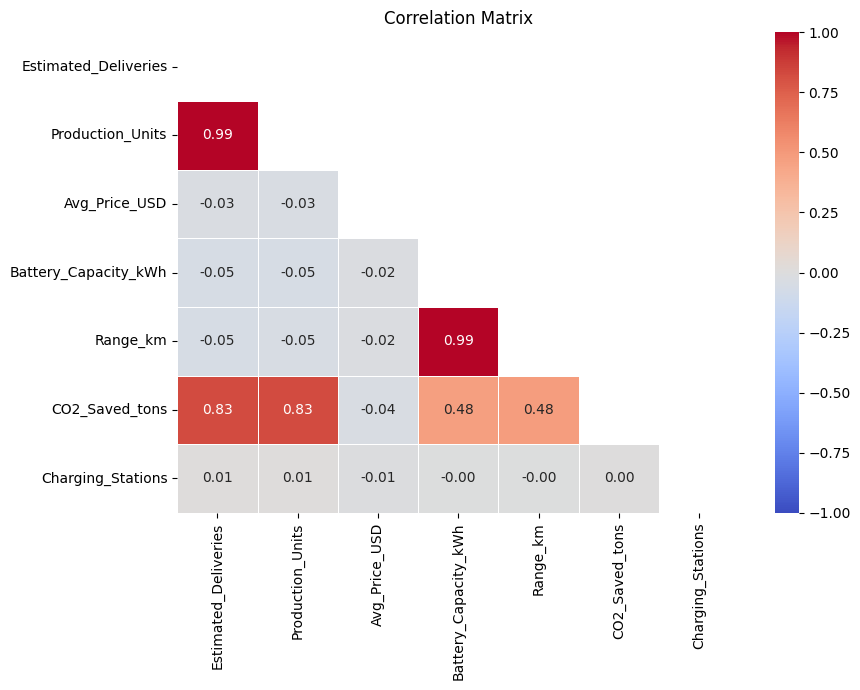

In [12]:
corr_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
             'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

corr = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 6. Encoding Techniques

In [13]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

df_enc = df_clean.copy()

le = LabelEncoder()
df_enc['Region_LE'] = le.fit_transform(df_enc['Region'])
print("Label Encoded — Region sample:")
print(df_enc[['Region', 'Region_LE']].drop_duplicates().sort_values('Region_LE'))

Label Encoded — Region sample:
          Region  Region_LE
1           Asia          0
7         Europe          1
4    Middle East          2
2  North America          3


In [14]:
df_ohe = pd.get_dummies(df_enc, columns=['Region', 'Model'], drop_first=True)
ohe_cols = [c for c in df_ohe.columns if c.startswith('Region_') or c.startswith('Model_')]
print("One-Hot Encoded columns:", ohe_cols)
df_ohe[ohe_cols].head(4)

One-Hot Encoded columns: ['Region_LE', 'Region_Europe', 'Region_Middle East', 'Region_North America', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y']


,Region_LE,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y
1,0,False,False,False,False,False,True,False
2,3,False,False,True,False,False,True,False
3,3,False,False,True,True,False,False,False
4,2,False,True,False,False,False,False,True


In [15]:
source_order = ['Official (Quarter)', 'Interpolated (Month)', 'Estimated (Region)']
oe = OrdinalEncoder(categories=[source_order])
df_ohe['Source_Ordinal'] = oe.fit_transform(df_enc[['Source_Type']])
print("Ordinal Encoded — Source_Type:")
print(df_ohe[['Source_Ordinal']].value_counts().sort_index())

Ordinal Encoded — Source_Type:
Source_Ordinal
0.0               869
1.0               861
2.0               855
Name: count, dtype: int64


## 7. Feature Scaling

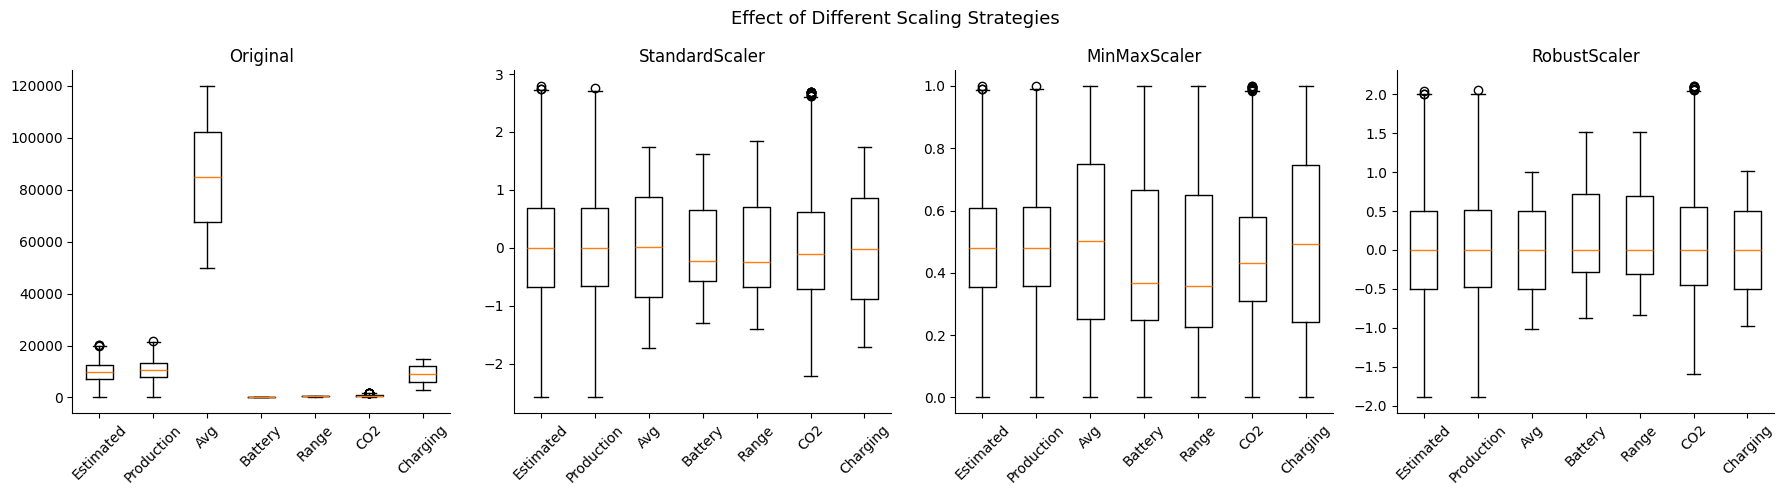

In [16]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

scale_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
              'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

scalers = {
    'Original':   df_clean[scale_cols].copy(),
    'StandardScaler': pd.DataFrame(StandardScaler().fit_transform(df_clean[scale_cols]), columns=scale_cols),
    'MinMaxScaler':   pd.DataFrame(MinMaxScaler().fit_transform(df_clean[scale_cols]),   columns=scale_cols),
    'RobustScaler':   pd.DataFrame(RobustScaler().fit_transform(df_clean[scale_cols]),   columns=scale_cols),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (name, data) in zip(axes, scalers.items()):
    ax.boxplot(data.values, labels=[c.split('_')[0] for c in scale_cols], vert=True)
    ax.set_title(name)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Effect of Different Scaling Strategies', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Feature Engineering

In [17]:
df_feat = df_ohe.copy()

df_feat['Utilization_Rate'] = df_feat['Estimated_Deliveries'] / df_feat['Production_Units'].replace(0, np.nan)

df_feat['Price_per_km'] = df_feat['Avg_Price_USD'] / df_feat['Range_km'].replace(0, np.nan)

df_feat['CO2_per_Delivery'] = df_feat['CO2_Saved_tons'] / df_feat['Estimated_Deliveries'].replace(0, np.nan)

df_feat['Stations_per_Delivery'] = df_feat['Charging_Stations'] / df_feat['Estimated_Deliveries'].replace(0, np.nan)

df_feat['Date_Ordinal'] = df_feat['Year'] * 12 + df_feat['Month']

df_feat['Year_sq'] = df_feat['Year'] ** 2

new_feats = ['Utilization_Rate', 'Price_per_km', 'CO2_per_Delivery',
             'Stations_per_Delivery', 'Date_Ordinal', 'Year_sq']
print("Engineered features — sample:")
df_feat[new_feats].describe().round(4)

Engineered features — sample:


,Utilization_Rate,Price_per_km,CO2_per_Delivery,Stations_per_Delivery,Date_Ordinal,Year_sq
count,2585.0000,2585.0000,2585.0000,2585.0000,2585.0000,2.585000e+03
mean,0.9328,180.7953,0.0746,1.4975,24246.5613,4.080433e+06
std,0.0372,61.9472,0.0179,6.2092,38.1241,1.278080e+04
min,0.8697,69.9025,0.0495,0.1695,24181.0000,4.060225e+06
25%,0.8999,133.0151,0.0627,0.6072,24214.0000,4.068289e+06
50%,0.9324,171.0725,0.0703,0.9089,24246.0000,4.080400e+06
75%,0.9644,220.4147,0.0875,1.3606,24280.0000,4.092529e+06
max,1.0000,359.3778,0.1079,230.6250,24312.0000,4.100625e+06


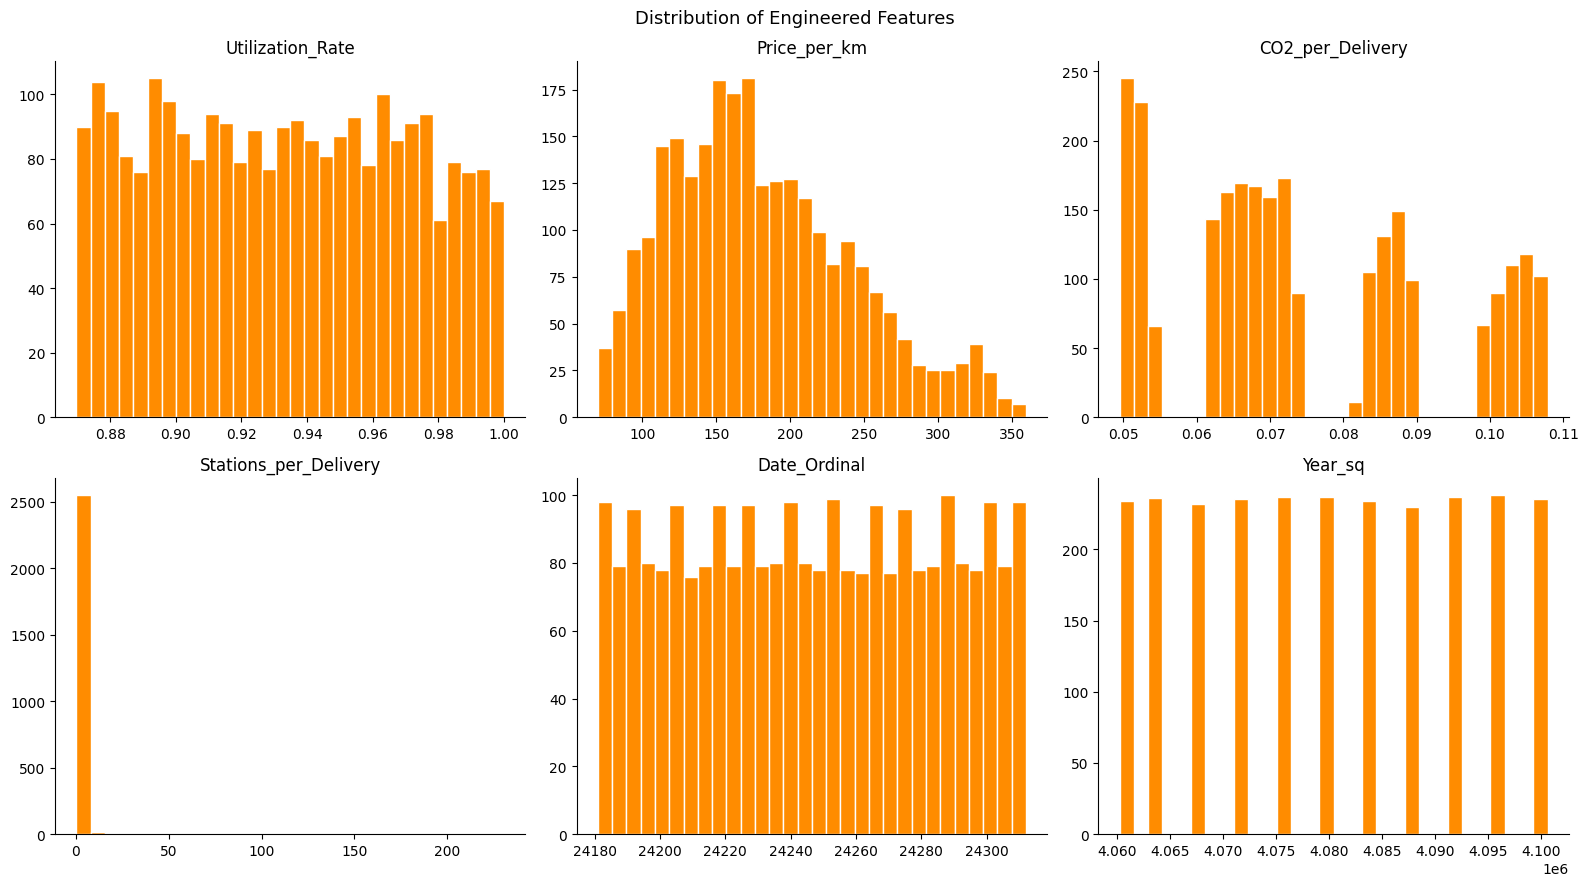

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.flatten(), new_feats):
    ax.hist(df_feat[feat].dropna(), bins=30, color='darkorange', edgecolor='white')
    ax.set_title(feat)

plt.suptitle('Distribution of Engineered Features', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Pipelines

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge

target = 'Avg_Price_USD'
drop_cols = ['Source_Type', 'Region_LE', 'Source_Ordinal', target]
feature_df = df_feat.drop(columns=[c for c in drop_cols if c in df_feat.columns], errors='ignore')
feature_df = feature_df.select_dtypes(include='number').dropna()

y = df_feat.loc[feature_df.index, target]
X = feature_df

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, X.columns.tolist())
])

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=10))
])

full_pipeline.fit(X_train, y_train)
print("Pipeline trained. Steps:", [step[0] for step in full_pipeline.steps])
print("Train R²:", round(full_pipeline.score(X_train, y_train), 4))
print("Test  R²:", round(full_pipeline.score(X_test,  y_test),  4))

Pipeline trained. Steps: ['preprocessor', 'model']
Train R²: 0.9025
Test  R²: 0.8978


## 10. Data Leakage

In [20]:
print("=== Data Leakage Demo ===")
print()
print("BAD — scaler fitted on entire dataset before split:")
scaler_bad = StandardScaler()
X_scaled_bad = scaler_bad.fit_transform(X)
X_tr_bad = X_scaled_bad[:int(0.8*len(X_scaled_bad))]
X_te_bad = X_scaled_bad[int(0.8*len(X_scaled_bad)):]
m_bad = Ridge(alpha=10)
m_bad.fit(X_tr_bad, y[:int(0.8*len(y))])
print(f"  R² (test) with leakage: {m_bad.score(X_te_bad, y[int(0.8*len(y)):]):.4f}")

print()
print("GOOD — scaler fitted only on training split (inside Pipeline):")
scaler_good = StandardScaler()
scaler_good.fit(X_train)
X_tr_good = scaler_good.transform(X_train)
X_te_good = scaler_good.transform(X_test)
m_good = Ridge(alpha=10)
m_good.fit(X_tr_good, y_train)
print(f"  R² (test) without leakage: {m_good.score(X_te_good, y_test):.4f}")

print()
print("Leakage inflates evaluation metrics artificially.")

=== Data Leakage Demo ===

BAD — scaler fitted on entire dataset before split:
  R² (test) with leakage: 0.9086

GOOD — scaler fitted only on training split (inside Pipeline):
  R² (test) without leakage: 0.8978

Leakage inflates evaluation metrics artificially.


## 11. Linear Regression

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression Results")
print(f"  MAE : {mean_absolute_error(y_test, y_pred_lr):,.2f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):,.2f}")
print(f"  R²  : {r2_score(y_test, y_pred_lr):.4f}")

Linear Regression Results
  MAE : 5,157.27
  RMSE: 6,356.34
  R²  : 0.8985


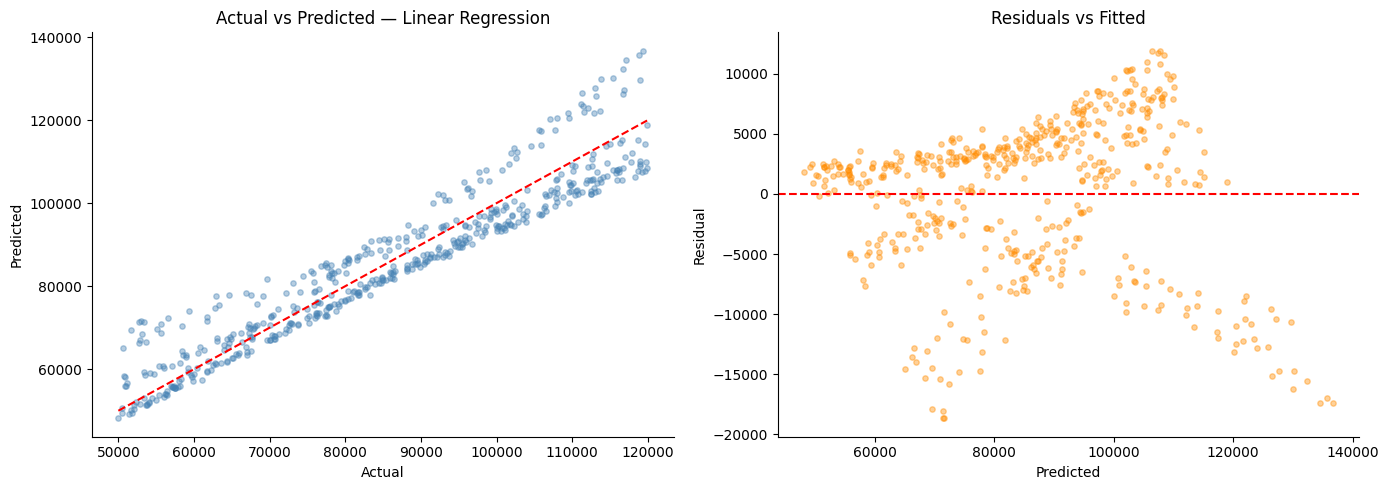

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_lr, alpha=0.4, color='steelblue', s=15)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted — Linear Regression')

residuals = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuals, alpha=0.4, color='darkorange', s=15)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Fitted')

plt.tight_layout()
plt.show()

## 12. Ridge Regression (L2)

Best alpha: 0.01  →  Test R²: 0.8987


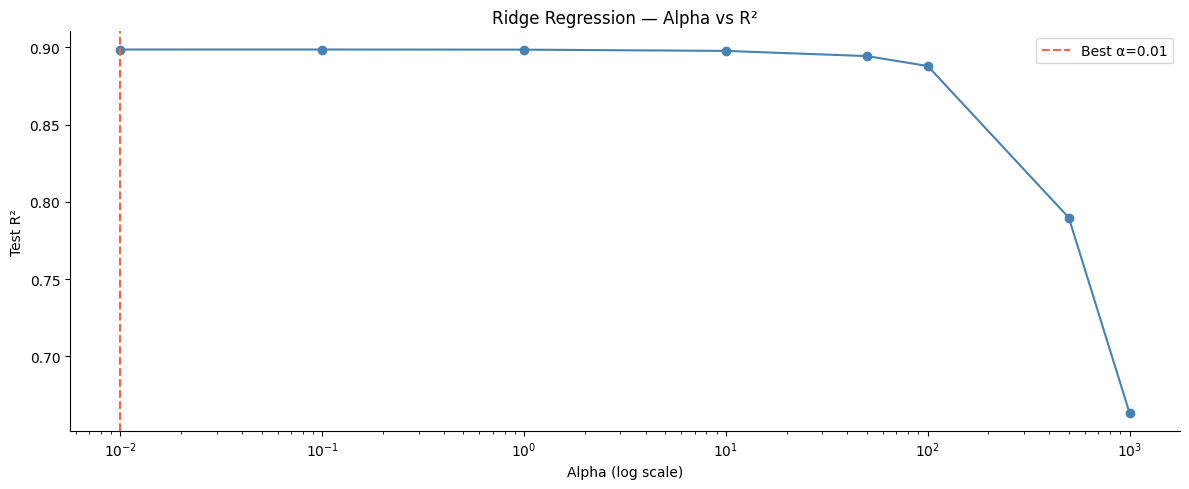

In [23]:
from sklearn.linear_model import Ridge

alphas = [0.01, 0.1, 1, 10, 50, 100, 500, 1000]
ridge_scores = []

for a in alphas:
    pipe = Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=a))])
    pipe.fit(X_train, y_train)
    ridge_scores.append(pipe.score(X_test, y_test))

best_alpha = alphas[np.argmax(ridge_scores)]
best_r2    = max(ridge_scores)
print(f"Best alpha: {best_alpha}  →  Test R²: {best_r2:.4f}")

fig, ax = plt.subplots()
ax.semilogx(alphas, ridge_scores, marker='o', color='steelblue')
ax.axvline(best_alpha, color='tomato', linestyle='--', label=f'Best α={best_alpha}')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Test R²')
ax.set_title('Ridge Regression — Alpha vs R²')
ax.legend()
plt.tight_layout()
plt.show()

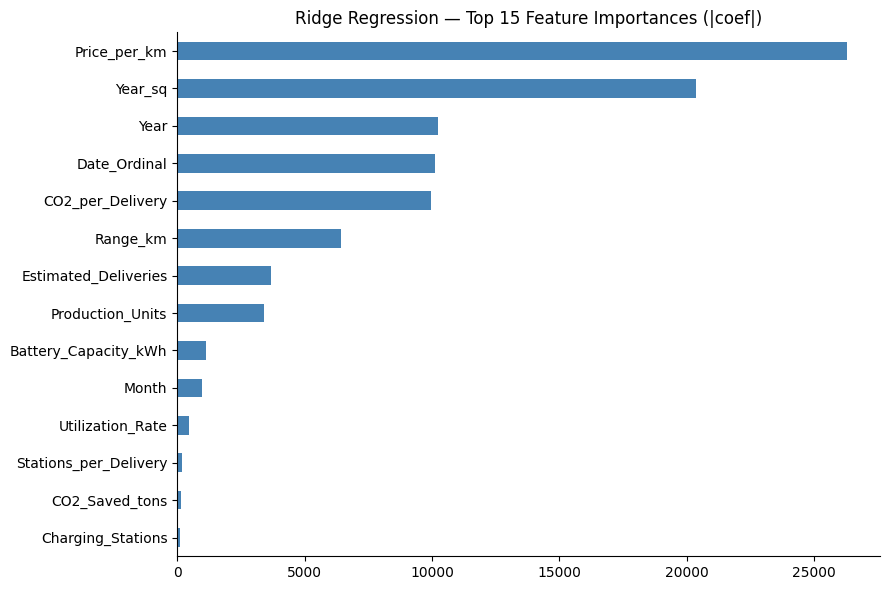

In [24]:
ridge_final = Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=best_alpha))])
ridge_final.fit(X_train, y_train)
y_pred_ridge = ridge_final.predict(X_test)

coefs = ridge_final.named_steps['m'].coef_
feat_names = X.columns.tolist()
coef_series = pd.Series(coefs, index=feat_names).abs().sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
coef_series.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Ridge Regression — Top 15 Feature Importances (|coef|)')
plt.tight_layout()
plt.show()

## 13. Lasso Regression (L1)

Best Lasso alpha: 10  →  Test R²: 0.8987


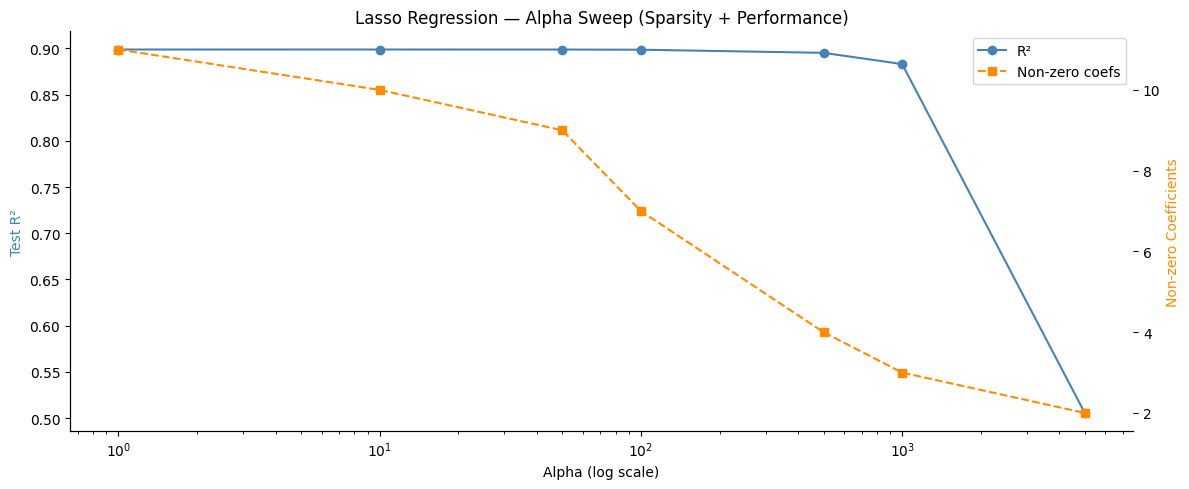

In [25]:
from sklearn.linear_model import Lasso

lasso_alphas = [1, 10, 50, 100, 500, 1000, 5000]
lasso_scores, lasso_nonzero = [], []

for a in lasso_alphas:
    pipe = Pipeline([('sc', StandardScaler()), ('m', Lasso(alpha=a, max_iter=5000))])
    pipe.fit(X_train, y_train)
    lasso_scores.append(pipe.score(X_test, y_test))
    lasso_nonzero.append(np.sum(pipe.named_steps['m'].coef_ != 0))

best_lasso_alpha = lasso_alphas[np.argmax(lasso_scores)]
print(f"Best Lasso alpha: {best_lasso_alpha}  →  Test R²: {max(lasso_scores):.4f}")

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.semilogx(lasso_alphas, lasso_scores,   marker='o', color='steelblue', label='R²')
ax2.semilogx(lasso_alphas, lasso_nonzero, marker='s', color='darkorange', linestyle='--', label='Non-zero coefs')
ax1.set_xlabel('Alpha (log scale)')
ax1.set_ylabel('Test R²', color='steelblue')
ax2.set_ylabel('Non-zero Coefficients', color='darkorange')
ax1.set_title('Lasso Regression — Alpha Sweep (Sparsity + Performance)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.tight_layout()
plt.show()

Features selected by Lasso: 10 / 14


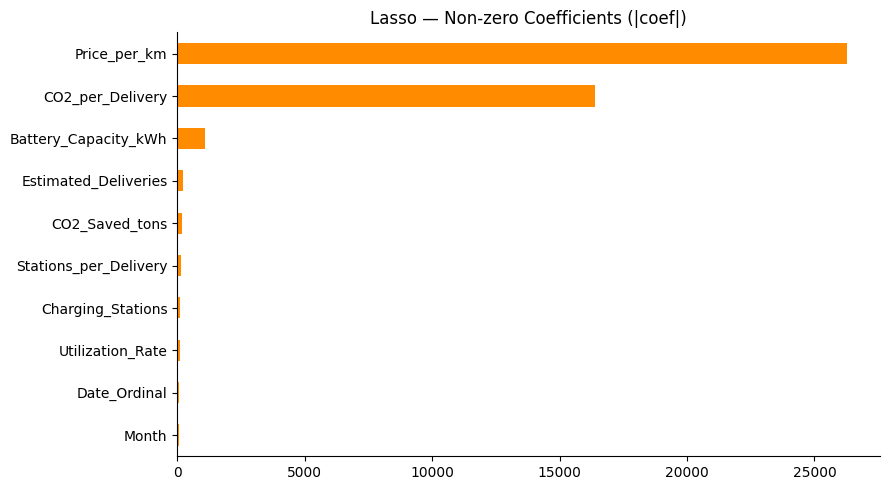

In [26]:
lasso_final = Pipeline([('sc', StandardScaler()), ('m', Lasso(alpha=best_lasso_alpha, max_iter=5000))])
lasso_final.fit(X_train, y_train)

lasso_coef = pd.Series(lasso_final.named_steps['m'].coef_, index=feat_names)
selected = lasso_coef[lasso_coef != 0].abs().sort_values(ascending=True)
print(f"Features selected by Lasso: {len(selected)} / {len(feat_names)}")

fig, ax = plt.subplots(figsize=(9, max(4, len(selected)//2)))
selected.plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Lasso — Non-zero Coefficients (|coef|)')
plt.tight_layout()
plt.show()

## 14. Evaluation Metrics

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models_eval = {
    'Linear Regression': lr,
    'Ridge (L2)':         ridge_final,
    'Lasso (L1)':         lasso_final,
}

rows = []
for name, m in models_eval.items():
    yp = m.predict(X_test)
    rows.append({
        'Model': name,
        'MAE':   round(mean_absolute_error(y_test, yp), 2),
        'RMSE':  round(np.sqrt(mean_squared_error(y_test, yp)), 2),
        'R²':    round(r2_score(y_test, yp), 4),
        'MAPE':  round(np.mean(np.abs((y_test - yp) / y_test)) * 100, 2)
    })

metrics_df = pd.DataFrame(rows).set_index('Model')
print(metrics_df)

                       MAE     RMSE      R²  MAPE
Model                                            
Linear Regression  5157.27  6356.34  0.8985  6.14
Ridge (L2)         5162.07  6350.43  0.8987  6.14
Lasso (L1)         5162.78  6349.41  0.8987  6.14


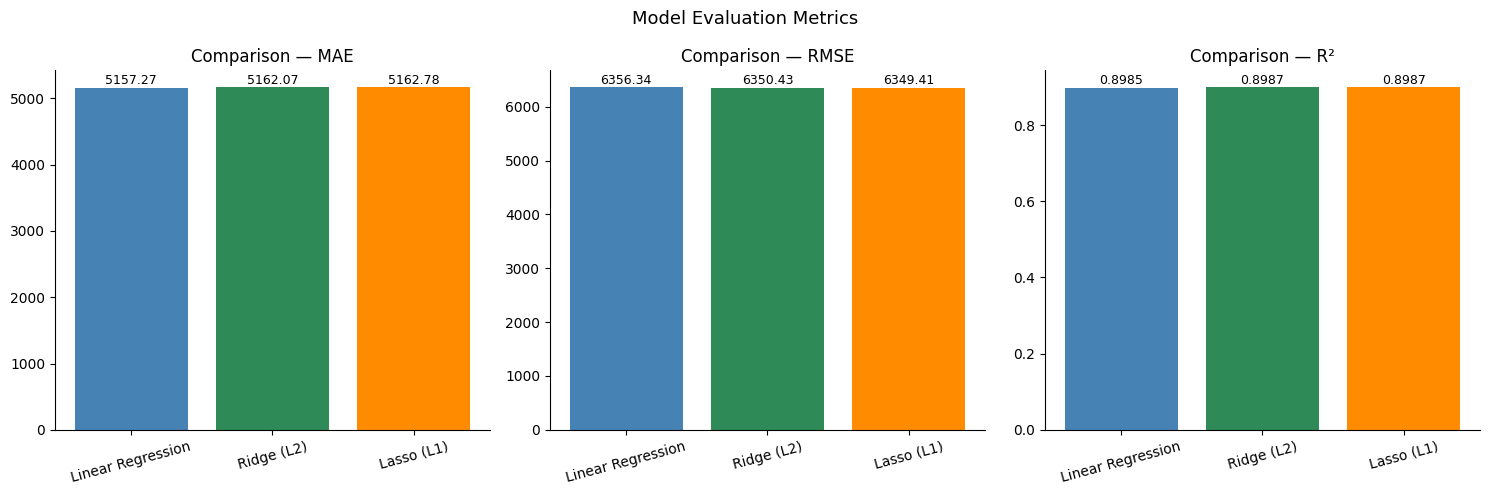

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['steelblue', 'seagreen', 'darkorange']

for i, metric in enumerate(['MAE', 'RMSE', 'R²']):
    vals = metrics_df[metric]
    axes[i].bar(vals.index, vals.values, color=colors)
    axes[i].set_title(f'Comparison — {metric}')
    axes[i].tick_params(axis='x', rotation=15)
    for j, v in enumerate(vals.values):
        axes[i].text(j, v + max(vals)*0.01, f'{v}', ha='center', fontsize=9)

plt.suptitle('Model Evaluation Metrics', fontsize=13)
plt.tight_layout()
plt.show()

## 15. Cross Validation

In [29]:
from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, m in models_eval.items():
    cv = cross_validate(m, X, y, cv=kf,
                        scoring=['r2', 'neg_mean_absolute_error'],
                        return_train_score=True)
    cv_results[name] = {
        'Train R² mean': round(cv['train_r2'].mean(), 4),
        'Test  R² mean': round(cv['test_r2'].mean(), 4),
        'Test  R² std':  round(cv['test_r2'].std(), 4),
        'Test MAE mean': round(-cv['test_neg_mean_absolute_error'].mean(), 2),
    }

cv_df = pd.DataFrame(cv_results).T
print(cv_df)

                   Train R² mean  Test  R² mean  Test  R² std  Test MAE mean
Linear Regression         0.9024         0.9000        0.0090        5120.24
Ridge (L2)                0.9023         0.9000        0.0090        5120.02
Lasso (L1)                0.9022         0.9003        0.0088        5112.89


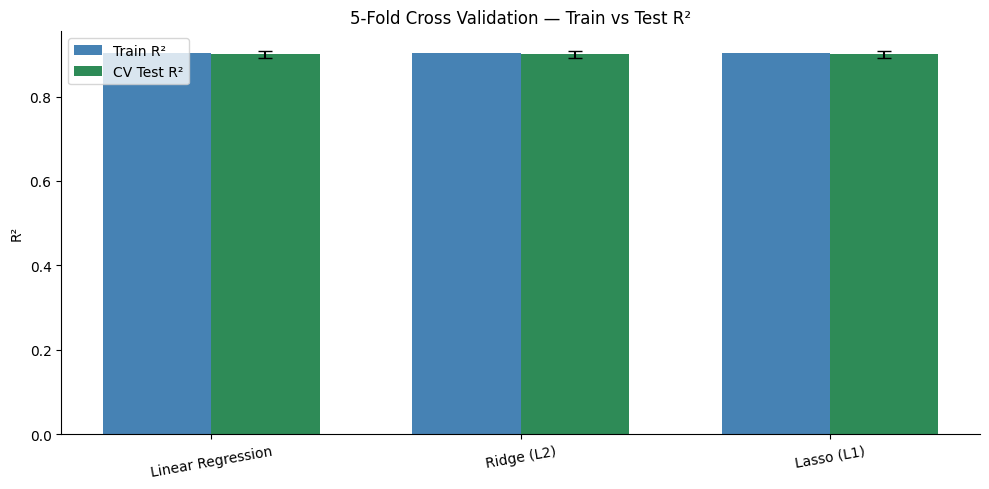

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(cv_df))
w = 0.35
ax.bar(x - w/2, cv_df['Train R² mean'], width=w, label='Train R²', color='steelblue')
ax.bar(x + w/2, cv_df['Test  R² mean'], width=w, label='CV Test R²', color='seagreen',
       yerr=cv_df['Test  R² std'], capsize=5)
ax.set_xticks(x)
ax.set_xticklabels(cv_df.index, rotation=10)
ax.set_ylabel('R²')
ax.set_title('5-Fold Cross Validation — Train vs Test R²')
ax.legend()
plt.tight_layout()
plt.show()

## 16. Hyperparameter Tuning

In [31]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor

gb_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('m',  GradientBoostingRegressor(random_state=42))
])

param_grid = {
    'm__n_estimators':   [100, 200, 300],
    'm__max_depth':      [3, 4, 5],
    'm__learning_rate':  [0.05, 0.1, 0.2],
    'm__subsample':      [0.8, 1.0]
}

grid_search = GridSearchCV(gb_pipe, param_grid, cv=3,
                           scoring='r2', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)

print("Best params  :", grid_search.best_params_)
print("Best CV R²   :", round(grid_search.best_score_, 4))
print("Test R²      :", round(grid_search.score(X_test, y_test), 4))

Best params  : {'m__learning_rate': 0.05, 'm__max_depth': 5, 'm__n_estimators': 300, 'm__subsample': 0.8}
Best CV R²   : 0.9979
Test R²      : 0.9985


In [32]:
from scipy.stats import randint, uniform

param_dist = {
    'm__n_estimators':  randint(100, 400),
    'm__max_depth':     randint(3, 7),
    'm__learning_rate': uniform(0.01, 0.3),
    'm__subsample':     uniform(0.7, 0.3)
}

rand_search = RandomizedSearchCV(gb_pipe, param_dist, n_iter=30, cv=3,
                                  scoring='r2', random_state=42, n_jobs=-1, verbose=0)
rand_search.fit(X_train, y_train)

print("RandomizedSearch best params:", rand_search.best_params_)
print("Best CV R²  :", round(rand_search.best_score_, 4))
print("Test R²     :", round(rand_search.score(X_test, y_test), 4))

RandomizedSearch best params: {'m__learning_rate': np.float64(0.023999698964084628), 'm__max_depth': 6, 'm__n_estimators': 370, 'm__subsample': np.float64(0.8368209952651107)}
Best CV R²  : 0.9981
Test R²     : 0.9988


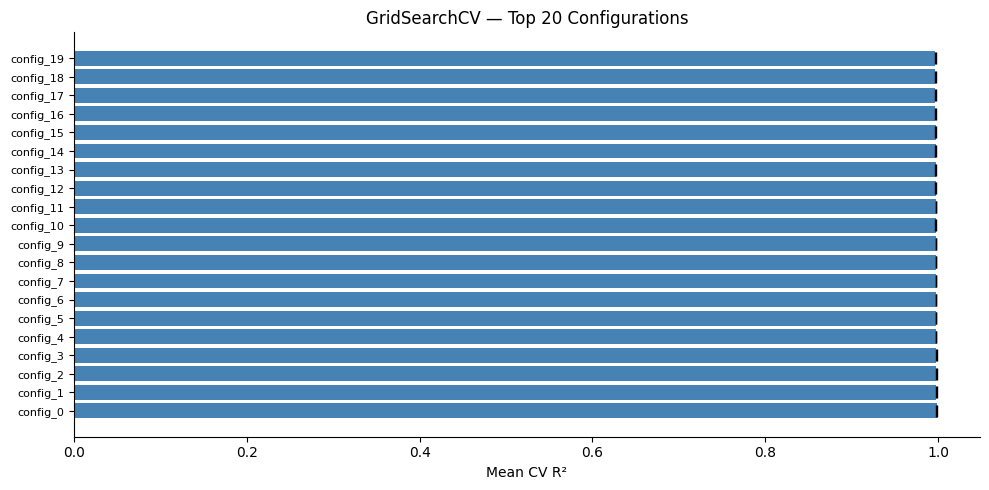

In [33]:
cv_results_gs = pd.DataFrame(grid_search.cv_results_)
top20 = cv_results_gs.nlargest(20, 'mean_test_score')

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(top20)), top20['mean_test_score'],
        xerr=top20['std_test_score'], color='steelblue', capsize=4)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([f"config_{i}" for i in range(len(top20))], fontsize=8)
ax.set_xlabel('Mean CV R²')
ax.set_title('GridSearchCV — Top 20 Configurations')
plt.tight_layout()
plt.show()

## 17. Time Series Components

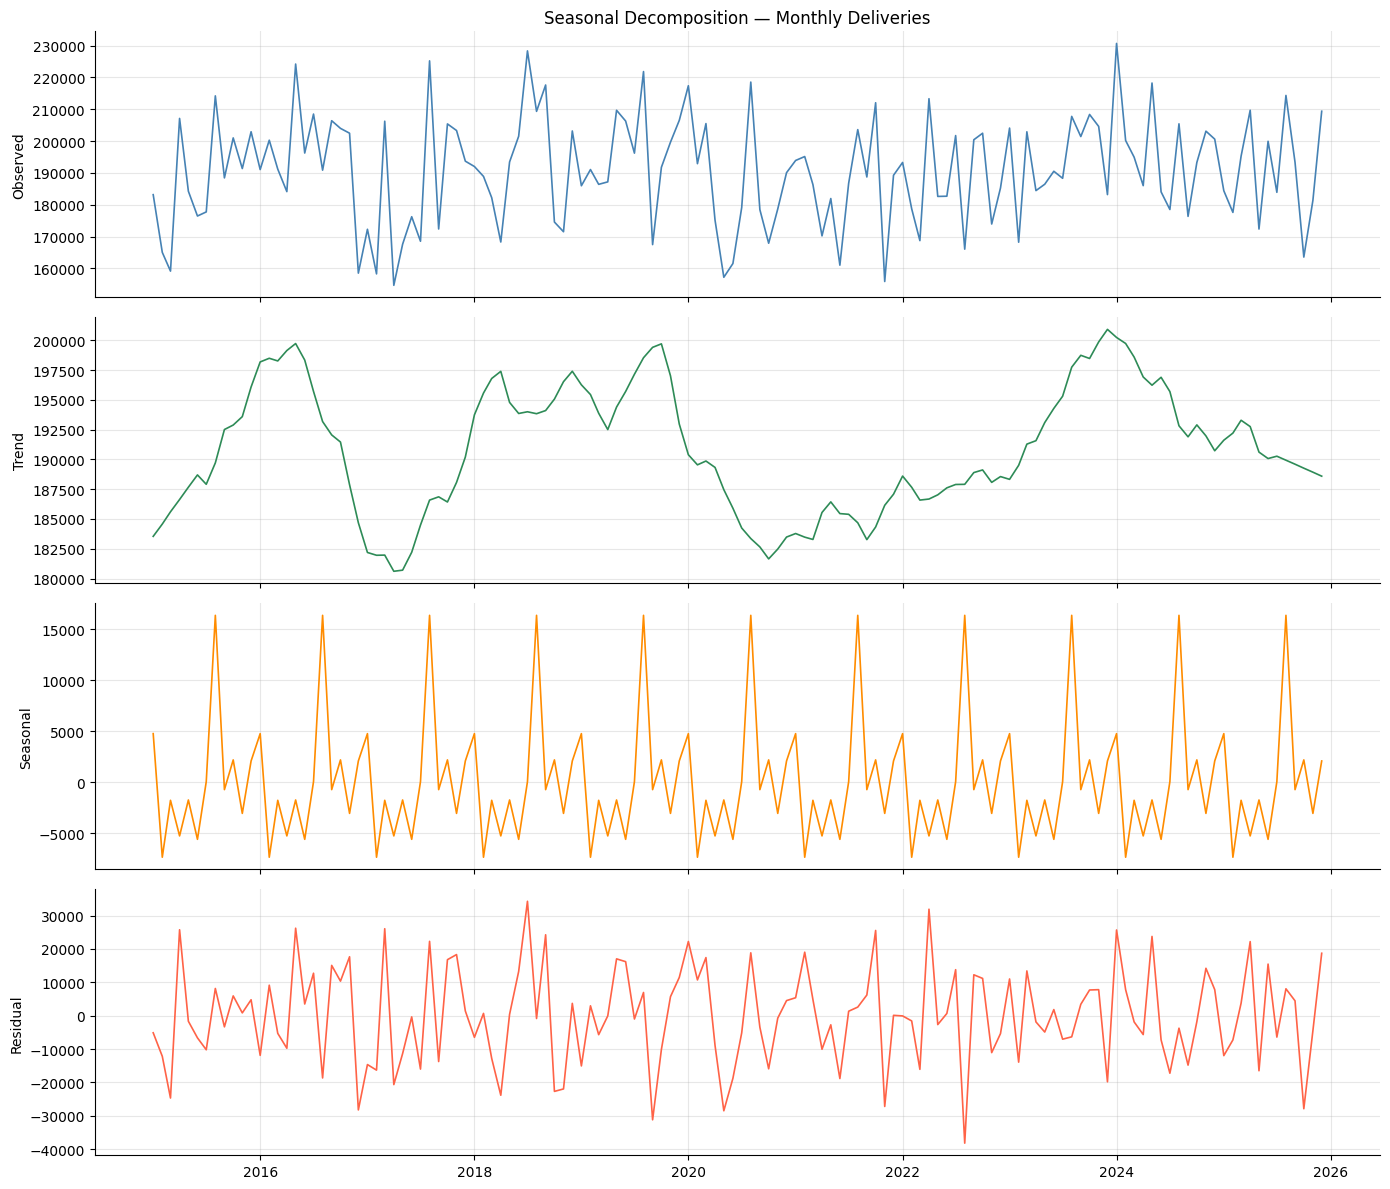

In [34]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts_raw = (df_clean
          .groupby(['Year', 'Month'])['Estimated_Deliveries']
          .sum()
          .reset_index()
          .sort_values(['Year', 'Month']))

ts_raw['Date'] = pd.to_datetime(ts_raw.assign(Day=1)[['Year', 'Month', 'Day']])
ts_raw = ts_raw.set_index('Date')['Estimated_Deliveries']
ts_raw = ts_raw.asfreq('MS')

decomp = seasonal_decompose(ts_raw, model='additive', period=12, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
labels = ['Observed', 'Trend', 'Seasonal', 'Residual']
series = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]
colors = ['steelblue', 'seagreen', 'darkorange', 'tomato']

for ax, label, s, c in zip(axes, labels, series, colors):
    ax.plot(s, color=c, linewidth=1.2)
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

axes[0].set_title('Seasonal Decomposition — Monthly Deliveries')
plt.tight_layout()
plt.show()

## 18. Stationarity

In [35]:
from statsmodels.tsa.stattools import adfuller, kpss

def adf_test(series, name=''):
    result = adfuller(series.dropna())
    print(f"ADF Test — {name}")
    print(f"  Statistic : {result[0]:.4f}")
    print(f"  p-value   : {result[1]:.4f}")
    print(f"  Stationary: {'Yes' if result[1] < 0.05 else 'No  ← needs differencing'}")
    print()

adf_test(ts_raw, 'Original Series')
adf_test(ts_raw.diff().dropna(), 'First-Differenced Series')

ADF Test — Original Series
  Statistic : -10.8978
  p-value   : 0.0000
  Stationary: Yes

ADF Test — First-Differenced Series
  Statistic : -6.5967
  p-value   : 0.0000
  Stationary: Yes



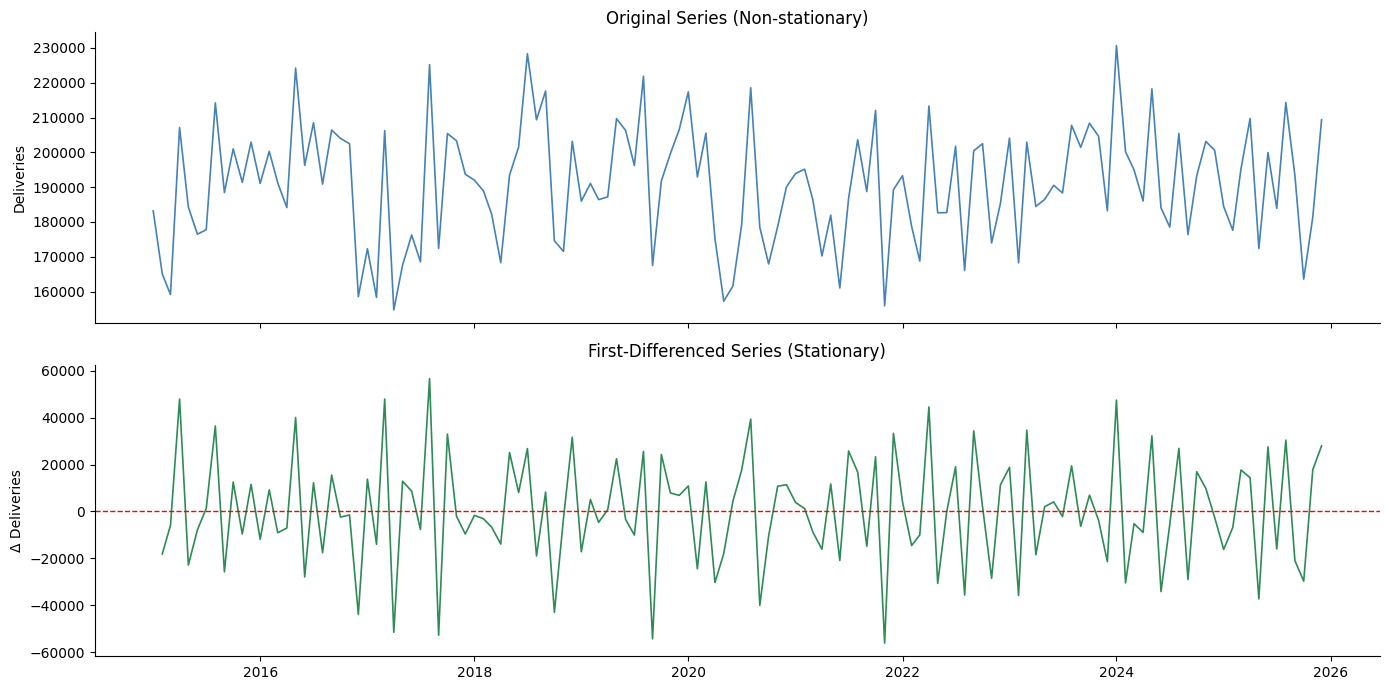

In [36]:
ts_diff = ts_raw.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(ts_raw,   color='steelblue', linewidth=1.2)
axes[0].set_title('Original Series (Non-stationary)')
axes[0].set_ylabel('Deliveries')

axes[1].plot(ts_diff, color='seagreen', linewidth=1.2)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('First-Differenced Series (Stationary)')
axes[1].set_ylabel('Δ Deliveries')

plt.tight_layout()
plt.show()

## 19. Lag Features

In [37]:
ts_df = ts_raw.reset_index()
ts_df.columns = ['Date', 'Deliveries']

for lag in [1, 2, 3, 6, 12]:
    ts_df[f'lag_{lag}'] = ts_df['Deliveries'].shift(lag)

lag_cols = [c for c in ts_df.columns if c.startswith('lag_')]
print("Lag feature sample (last 6 rows):")
ts_df[['Date', 'Deliveries'] + lag_cols].tail(6)

Lag feature sample (last 6 rows):


,Date,Deliveries,lag_1,lag_2,lag_3,lag_6,lag_12
126,2025-07-01,183916,199951.0,172377.0,209709.0,184411.0,178516.0
127,2025-08-01,214357,183916.0,199951.0,172377.0,177605.0,205440.0
128,2025-09-01,193337,214357.0,183916.0,199951.0,195289.0,176362.0
129,2025-10-01,163570,193337.0,214357.0,183916.0,209709.0,193298.0
130,2025-11-01,181403,163570.0,193337.0,214357.0,172377.0,203136.0
131,2025-12-01,209391,181403.0,163570.0,193337.0,199951.0,200628.0


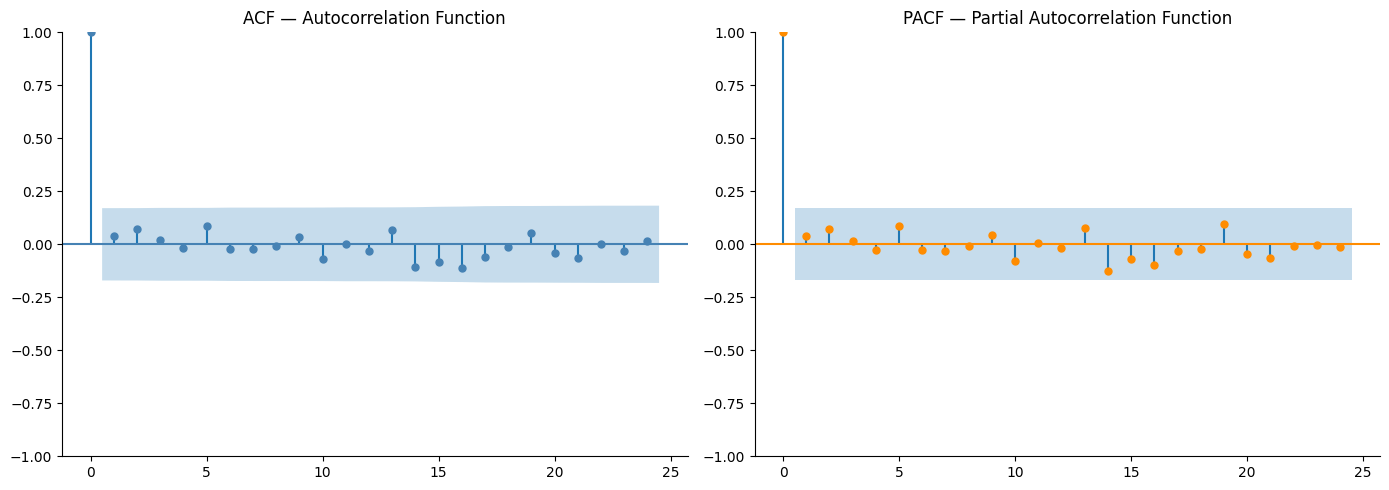

In [38]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(ts_raw,  lags=24, ax=axes[0], color='steelblue')
plot_pacf(ts_raw, lags=24, ax=axes[1], color='darkorange')
axes[0].set_title('ACF — Autocorrelation Function')
axes[1].set_title('PACF — Partial Autocorrelation Function')
plt.tight_layout()
plt.show()

## 20. Rolling Statistics

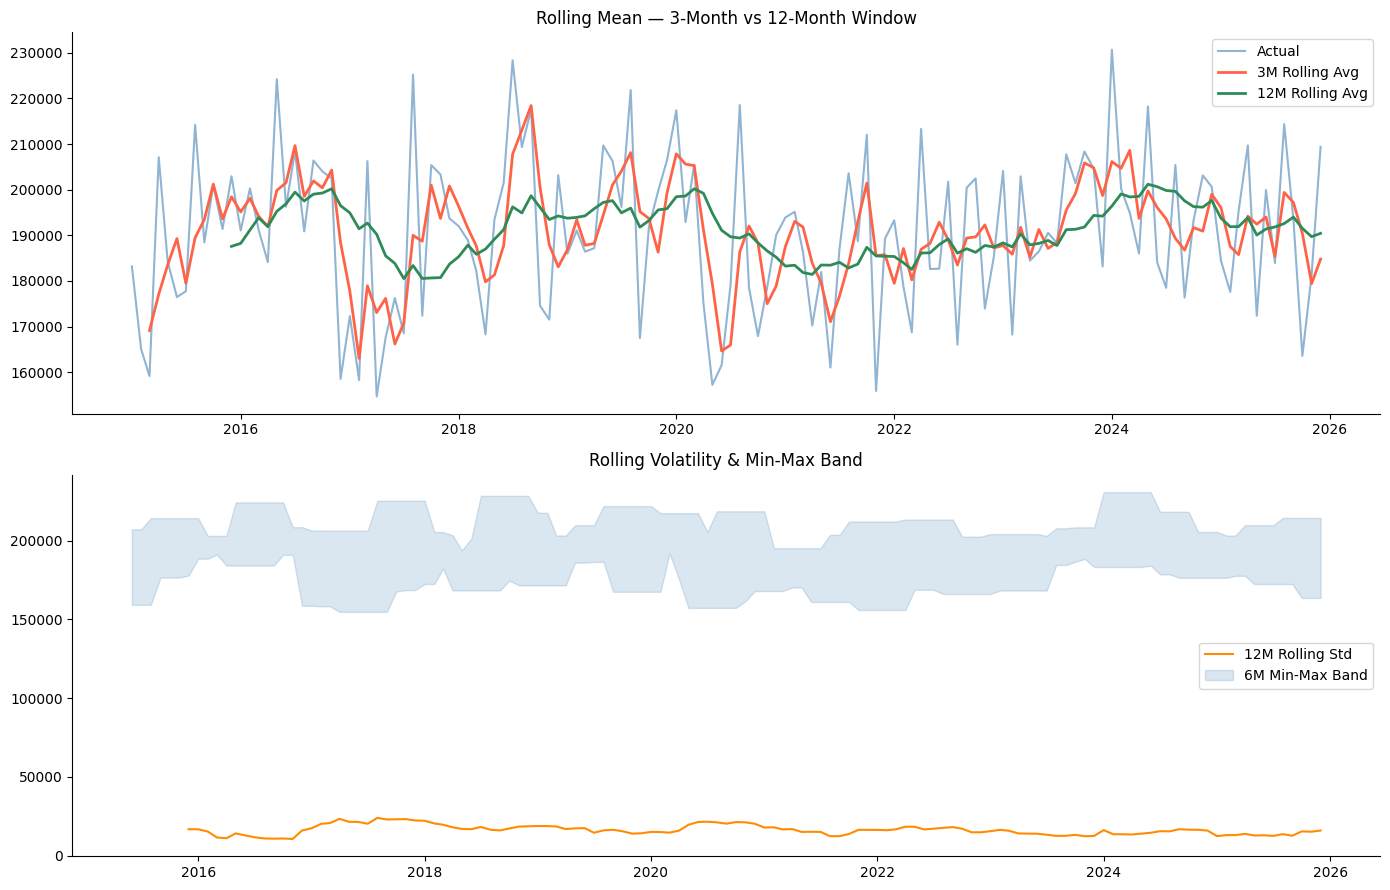

In [39]:
ts_df['roll_mean_3']  = ts_df['Deliveries'].rolling(3).mean()
ts_df['roll_mean_12'] = ts_df['Deliveries'].rolling(12).mean()
ts_df['roll_std_12']  = ts_df['Deliveries'].rolling(12).std()
ts_df['roll_min_6']   = ts_df['Deliveries'].rolling(6).min()
ts_df['roll_max_6']   = ts_df['Deliveries'].rolling(6).max()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(ts_df['Date'], ts_df['Deliveries'],      label='Actual',       color='steelblue',  alpha=0.6)
axes[0].plot(ts_df['Date'], ts_df['roll_mean_3'],     label='3M Rolling Avg',  color='tomato',     linewidth=2)
axes[0].plot(ts_df['Date'], ts_df['roll_mean_12'],    label='12M Rolling Avg', color='seagreen',   linewidth=2)
axes[0].set_title('Rolling Mean — 3-Month vs 12-Month Window')
axes[0].legend()

axes[1].plot(ts_df['Date'], ts_df['roll_std_12'],  color='darkorange', linewidth=1.5, label='12M Rolling Std')
axes[1].fill_between(ts_df['Date'],
                     ts_df['roll_min_6'], ts_df['roll_max_6'],
                     alpha=0.2, color='steelblue', label='6M Min-Max Band')
axes[1].set_title('Rolling Volatility & Min-Max Band')
axes[1].legend()

plt.tight_layout()
plt.show()

## 21. Forecasting

In [40]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train_ts = ts_raw[:'2023']
test_ts  = ts_raw['2024':]

sarima = SARIMAX(train_ts,
                 order=(1, 1, 1),
                 seasonal_order=(1, 1, 1, 12),
                 enforce_stationarity=False,
                 enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)
print(sarima_fit.summary().tables[0])

                                     SARIMAX Results                                      
Dep. Variable:               Estimated_Deliveries   No. Observations:                  108
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -925.643
Date:                            Sun, 31 May 2026   AIC                           1861.286
Time:                                    15:58:33   BIC                           1873.258
Sample:                                01-01-2015   HQIC                          1866.089
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         


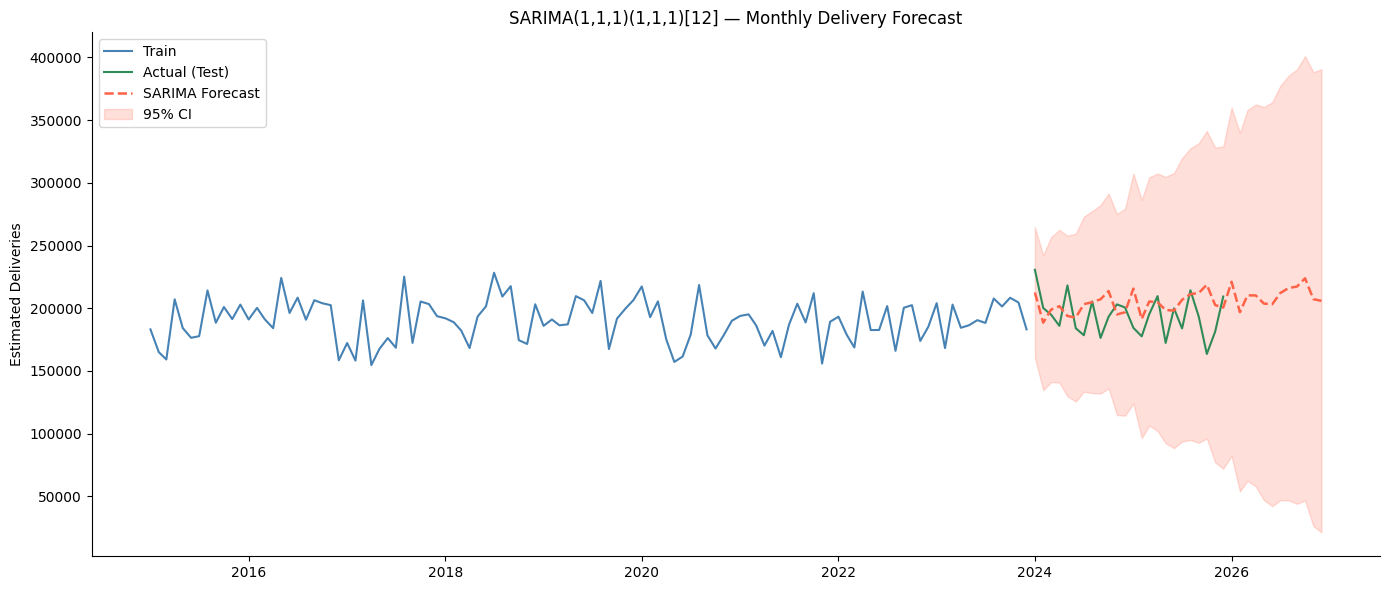

In [41]:
n_forecast = len(test_ts) + 12
forecast_obj = sarima_fit.get_forecast(steps=n_forecast)
forecast_mean = forecast_obj.predicted_mean
forecast_ci   = forecast_obj.conf_int()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train_ts.index, train_ts.values, label='Train', color='steelblue')
ax.plot(test_ts.index,  test_ts.values,  label='Actual (Test)', color='seagreen')
ax.plot(forecast_mean.index, forecast_mean.values, label='SARIMA Forecast',
        color='tomato', linestyle='--', linewidth=1.8)
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                alpha=0.2, color='tomato', label='95% CI')
ax.set_title('SARIMA(1,1,1)(1,1,1)[12] — Monthly Delivery Forecast')
ax.set_ylabel('Estimated Deliveries')
ax.legend()
plt.tight_layout()
plt.show()

In [42]:
test_pred = sarima_fit.get_prediction(start=test_ts.index[0],
                                       end=test_ts.index[-1])
test_mean = test_pred.predicted_mean

ts_mae  = mean_absolute_error(test_ts, test_mean)
ts_rmse = np.sqrt(mean_squared_error(test_ts, test_mean))
ts_r2   = r2_score(test_ts, test_mean)
mape    = np.mean(np.abs((test_ts - test_mean) / test_ts)) * 100

print("SARIMA Forecast Evaluation (test period):")
print(f"  MAE  : {ts_mae:,.0f}")
print(f"  RMSE : {ts_rmse:,.0f}")
print(f"  R²   : {ts_r2:.4f}")
print(f"  MAPE : {mape:.2f}%")

SARIMA Forecast Evaluation (test period):
  MAE  : 16,202
  RMSE : 20,315
  R²   : -0.6797
  MAPE : 8.73%


## 22. Chronological Split

In [43]:
ts_ml = ts_df.dropna().copy()

cutoff_date = pd.Timestamp('2023-01-01')
train_idx = ts_ml['Date'] < cutoff_date
test_idx  = ts_ml['Date'] >= cutoff_date

lag_feat_cols = [c for c in ts_ml.columns if c.startswith(('lag_', 'roll_'))]
feat_cols = ['Deliveries'] + lag_feat_cols

ts_ml_feats = ts_ml[['Date'] + feat_cols].dropna()

train_ml = ts_ml_feats[ts_ml_feats['Date'] <  cutoff_date]
test_ml  = ts_ml_feats[ts_ml_feats['Date'] >= cutoff_date]

print(f"Train size : {len(train_ml)} rows  ({train_ml['Date'].min().date()} → {train_ml['Date'].max().date()})")
print(f"Test  size : {len(test_ml)} rows  ({test_ml['Date'].min().date()} → {test_ml['Date'].max().date()})")
print()
print("No future data leaks — test is strictly after train.")

Train size : 84 rows  (2016-01-01 → 2022-12-01)
Test  size : 36 rows  (2023-01-01 → 2025-12-01)

No future data leaks — test is strictly after train.


In [44]:
from sklearn.ensemble import GradientBoostingRegressor as GBR

X_tr_ts = train_ml[lag_feat_cols]
y_tr_ts = train_ml['Deliveries']
X_te_ts = test_ml[lag_feat_cols]
y_te_ts = test_ml['Deliveries']

gb_ts = GBR(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
gb_ts.fit(X_tr_ts, y_tr_ts)

y_pred_ts = gb_ts.predict(X_te_ts)

print("GBR Forecast on Chronological Split:")
print(f"  MAE  : {mean_absolute_error(y_te_ts, y_pred_ts):,.0f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_te_ts, y_pred_ts)):,.0f}")
print(f"  R²   : {r2_score(y_te_ts, y_pred_ts):.4f}")

GBR Forecast on Chronological Split:
  MAE  : 6,615
  RMSE : 8,055
  R²   : 0.6933


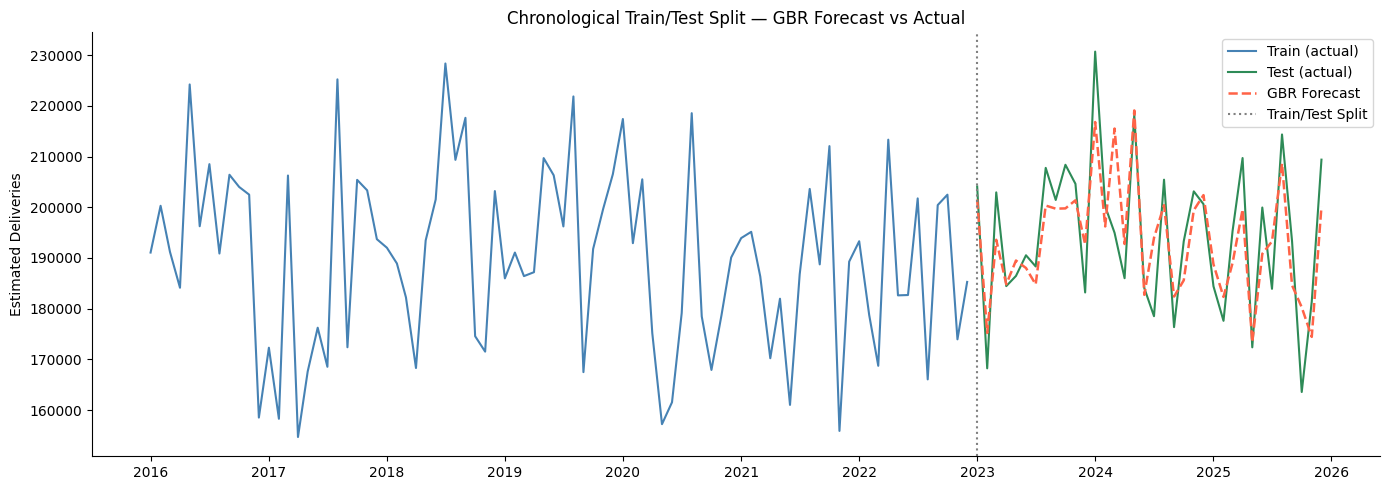

In [45]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_ml['Date'], y_tr_ts.values,  label='Train (actual)',   color='steelblue')
ax.plot(test_ml['Date'],  y_te_ts.values,  label='Test (actual)',    color='seagreen')
ax.plot(test_ml['Date'],  y_pred_ts,       label='GBR Forecast',     color='tomato', linestyle='--', linewidth=1.8)
ax.axvline(cutoff_date, color='gray', linestyle=':', linewidth=1.5, label='Train/Test Split')
ax.set_title('Chronological Train/Test Split — GBR Forecast vs Actual')
ax.set_ylabel('Estimated Deliveries')
ax.legend()
plt.tight_layout()
plt.show()